# 1. Exploratory Data Analysis


## Goal
Understand the data well enough to make informed modeling decisions. Specifically:

1. What are we forecasting, at what granularity, and how much history do we have?
2. What signals are strong enough to encode as features (seasonality, holidays, staffing)?
3. What data quality issues (outliers, gaps, heavy tails) will the model have to survive?
4. Is the series stationary, and does that constrain which model families make sense?

## Scope
- 4 portfolios (A/B/C/D), each with daily and 30-min interval data
- 3 target metrics: Call Volume, CCT, Abandon Rate
- Daily staffing as an exogenous covariate
- Forecast horizon: August 2025 at 30-min granularity


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import acf as compute_acf, adfuller, kpss
from statsmodels.tsa.seasonal import STL
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


DATA_FILE = "Data for Datathon (Revised).xlsx"
PORTFOLIOS = ['A', 'B', 'C', 'D']
MONTH_MAP = {'January': 1, 'February': 2, 'March': 3, 'April': 4,
             'May': 5, 'June': 6, 'July': 7, 'August': 8,
             'September': 9, 'October': 10, 'November': 11, 'December': 12}

US_HOLIDAYS = set([
    datetime(2024, 1, 1), datetime(2024, 1, 15), datetime(2024, 2, 19),
    datetime(2024, 5, 27), datetime(2024, 7, 4), datetime(2024, 9, 2),
    datetime(2024, 10, 14), datetime(2024, 11, 11), datetime(2024, 11, 28),
    datetime(2024, 12, 25),
    datetime(2025, 1, 1), datetime(2025, 1, 20), datetime(2025, 2, 17),
    datetime(2025, 5, 26), datetime(2025, 7, 4), datetime(2025, 9, 1),
    datetime(2025, 10, 13), datetime(2025, 11, 11), datetime(2025, 11, 27),
    datetime(2025, 12, 25)
])

## 1. Load Data

In [2]:
print("Loading data...")

daily_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(DATA_FILE, sheet_name=f"{p} - Daily")
    df['Date'] = pd.to_datetime(df['Date'].str.strip().str[:8], format='%m/%d/%y')
    df = df.sort_values('Date').reset_index(drop=True)
    df['dow'] = df['Date'].dt.dayofweek
    df['dow_name'] = df['Date'].dt.day_name()
    df['month'] = df['Date'].dt.month
    df['day_of_month'] = df['Date'].dt.day
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_holiday'] = df['Date'].isin(US_HOLIDAYS).astype(int)
    df['year'] = df['Date'].dt.year
    daily_data[p] = df

interval_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(DATA_FILE, sheet_name=f"{p} - Interval")
    df = df.dropna(subset=['Interval', 'Call Volume']).reset_index(drop=True)
    df['Interval'] = df['Interval'].astype(str)
    def parse_interval(val):
        val = str(val).strip()
        if 'days' in val:
            return val.split(' ')[-1][:5]
        return val[:5] if len(val) >= 5 else val
    df['Interval_str'] = df['Interval'].apply(parse_interval)
    df['half_hour'] = df['Interval_str'].apply(
        lambda x: int(x.split(':')[0]) * 2 + (1 if int(x.split(':')[1]) >= 30 else 0)
    )
    df['month_num'] = df['Month'].map(MONTH_MAP)
    dates = []
    for _, row in df.iterrows():
        try:
            dates.append(datetime(2025, row['month_num'], row['Day']))
        except ValueError:
            dates.append(None)
    df['Date'] = dates
    df = df.dropna(subset=['Date']).reset_index(drop=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df['dow'] = df['Date'].dt.dayofweek
    df['dow_name'] = df['Date'].dt.day_name()
    interval_data[p] = df

staffing = pd.read_excel(DATA_FILE, sheet_name="Daily Staffing")
staffing.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
staffing['Date'] = pd.to_datetime(staffing['Date'])

metrics = ['Call Volume', 'CCT', 'Abandon Rate']
interval_metrics = ['Call Volume', 'CCT', 'Abandoned Rate']
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print("Data loaded.")
for p in PORTFOLIOS:
    d = daily_data[p]
    i = interval_data[p]
    print(f"  Portfolio {p}: {len(d)} daily rows ({d['Date'].min().date()} to {d['Date'].max().date()}), {len(i)} interval rows")

Loading data...
Data loaded.
  Portfolio A: 731 daily rows (2024-01-01 to 2025-12-31), 3995 interval rows
  Portfolio B: 731 daily rows (2024-01-01 to 2025-12-31), 4185 interval rows
  Portfolio C: 731 daily rows (2024-01-01 to 2025-12-31), 4290 interval rows
  Portfolio D: 731 daily rows (2024-01-01 to 2025-12-31), 4285 interval rows


## 2. Data Quality

In [3]:
print("=" * 80)
print("DAILY DATA QUALITY")
print("=" * 80)
for p in PORTFOLIOS:
    df = daily_data[p]
    n = len(df)
    date_range = (df['Date'].max() - df['Date'].min()).days + 1
    missing_dates = date_range - n
    dups = df.duplicated(subset=['Date']).sum()

    print(f"\nPortfolio {p}:")
    print(f"  Rows: {n}, Expected: {date_range}, Missing dates: {missing_dates}, Duplicates: {dups}")
    for metric in metrics:
        na = df[metric].isna().sum()
        zeros = (df[metric] == 0).sum()
        print(f"  {metric}: NaN={na}, Zeros={zeros}")

print("\n" + "=" * 80)
print("INTERVAL DATA QUALITY")
print("=" * 80)
for p in PORTFOLIOS:
    idf = interval_data[p]
    print(f"\nPortfolio {p}:")
    print(f"  Rows: {len(idf)}, Months: {sorted(idf['Month'].unique())}")

    intervals_per_day = idf.groupby('Date').size()
    incomplete_days = intervals_per_day[intervals_per_day < 48]
    if len(incomplete_days) > 0:
        print(f"  Days with < 48 intervals: {len(incomplete_days)}")
        for date, count in incomplete_days.items():
            print(f"    {date.date()}: {count} intervals")
    else:
        print(f"  All {len(intervals_per_day)} days have 48 intervals")

    for metric in interval_metrics:
        na = idf[metric].isna().sum()
        print(f"  {metric}: NaN={na}")

    zero_vol = (idf['Call Volume'] == 0).sum()
    print(f"  Zero-volume intervals: {zero_vol} ({zero_vol/len(idf)*100:.1f}%)")

DAILY DATA QUALITY

Portfolio A:
  Rows: 731, Expected: 731, Missing dates: 0, Duplicates: 0
  Call Volume: NaN=24, Zeros=0
  CCT: NaN=24, Zeros=0
  Abandon Rate: NaN=30, Zeros=1

Portfolio B:
  Rows: 731, Expected: 731, Missing dates: 0, Duplicates: 0
  Call Volume: NaN=20, Zeros=0
  CCT: NaN=29, Zeros=0
  Abandon Rate: NaN=25, Zeros=0

Portfolio C:
  Rows: 731, Expected: 731, Missing dates: 0, Duplicates: 0
  Call Volume: NaN=20, Zeros=0
  CCT: NaN=14, Zeros=0
  Abandon Rate: NaN=10, Zeros=0

Portfolio D:
  Rows: 731, Expected: 731, Missing dates: 0, Duplicates: 0
  Call Volume: NaN=10, Zeros=0
  CCT: NaN=32, Zeros=0
  Abandon Rate: NaN=0, Zeros=0

INTERVAL DATA QUALITY

Portfolio A:
  Rows: 3995, Months: ['April', 'June', 'May']
  Days with < 48 intervals: 87
    2025-04-01: 37 intervals
    2025-04-02: 46 intervals
    2025-04-03: 45 intervals
    2025-04-04: 45 intervals
    2025-04-05: 46 intervals
    2025-04-06: 43 intervals
    2025-04-07: 38 intervals
    2025-04-08: 46 inter

## 3. Interval-Level Distributions

Since we predict at 30-min granularity, stats at this level matter more than daily.

Portfolio  Metric                   Mean     Median        Std        Min        Max   Zeros%     Skew     Kurt
----------------------------------------------------------------------------------------------------------------
A          Call Volume             85.44      43.00      89.69       0.00     317.00     1.3%     0.68    -1.08
A          CCT                    315.79     310.79     135.82       0.00    2799.00     0.0%     6.70    89.53
A          Abandoned Rate           0.02       0.00       0.08       0.00       1.00    68.8%     6.92    60.60

B          Call Volume            171.60     129.00     158.73       0.00     574.00     0.5%     0.50    -1.16
B          CCT                    323.21     323.07     114.81      17.00    3270.00     0.0%     8.18   148.40
B          Abandoned Rate           0.02       0.00       0.07       0.00       1.00    53.5%     8.15    79.06

C          Call Volume            388.48     286.00     359.77       0.00    1200.00     0.0%     0.5

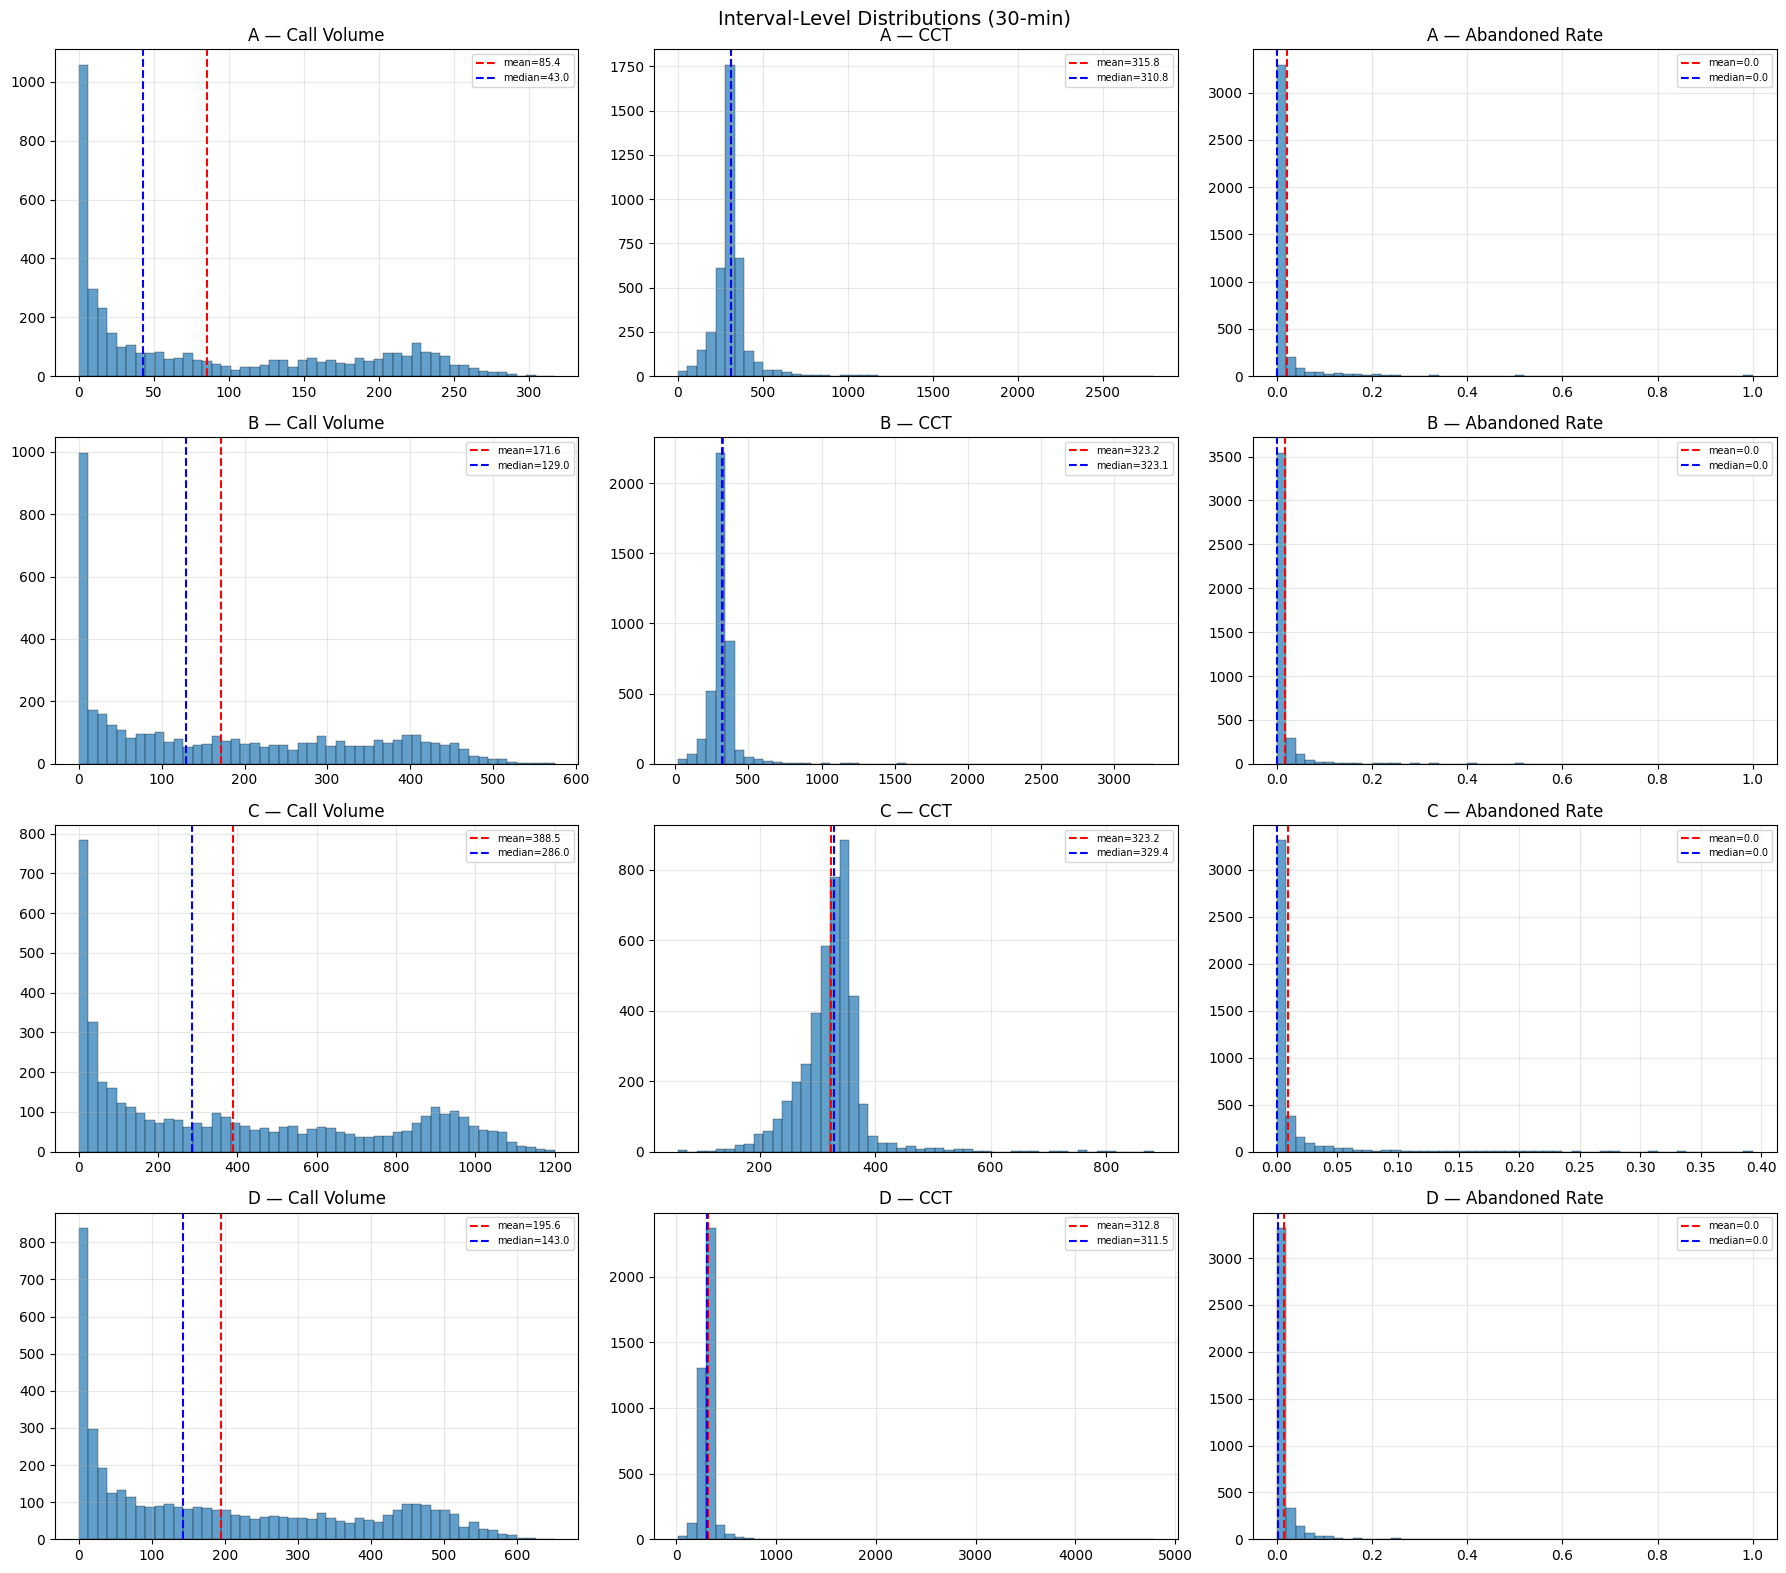

In [4]:
print(f"{'Portfolio':<10} {'Metric':<18} {'Mean':>10} {'Median':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Zeros%':>8} {'Skew':>8} {'Kurt':>8}")
print("-" * 112)
for p in PORTFOLIOS:
    idf = interval_data[p]
    for metric in interval_metrics:
        vals = idf[metric].dropna()
        print(f"{p:<10} {metric:<18} {vals.mean():>10.2f} {vals.median():>10.2f} {vals.std():>10.2f} "
              f"{vals.min():>10.2f} {vals.max():>10.2f} {(vals==0).sum()/len(vals)*100:>7.1f}% "
              f"{vals.skew():>8.2f} {vals.kurtosis():>8.2f}")
    print()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for j, p in enumerate(PORTFOLIOS):
    idf = interval_data[p]
    for i, metric in enumerate(interval_metrics):
        ax = axes[j, i]
        vals = idf[metric].dropna()
        ax.hist(vals, bins=50, alpha=0.7, edgecolor='black', linewidth=0.3)
        ax.axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.1f}')
        ax.axvline(vals.median(), color='blue', linestyle='--', label=f'median={vals.median():.1f}')
        ax.set_title(f'{p} — {metric}')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
fig.suptitle('Interval-Level Distributions (30-min)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Daily Time Series

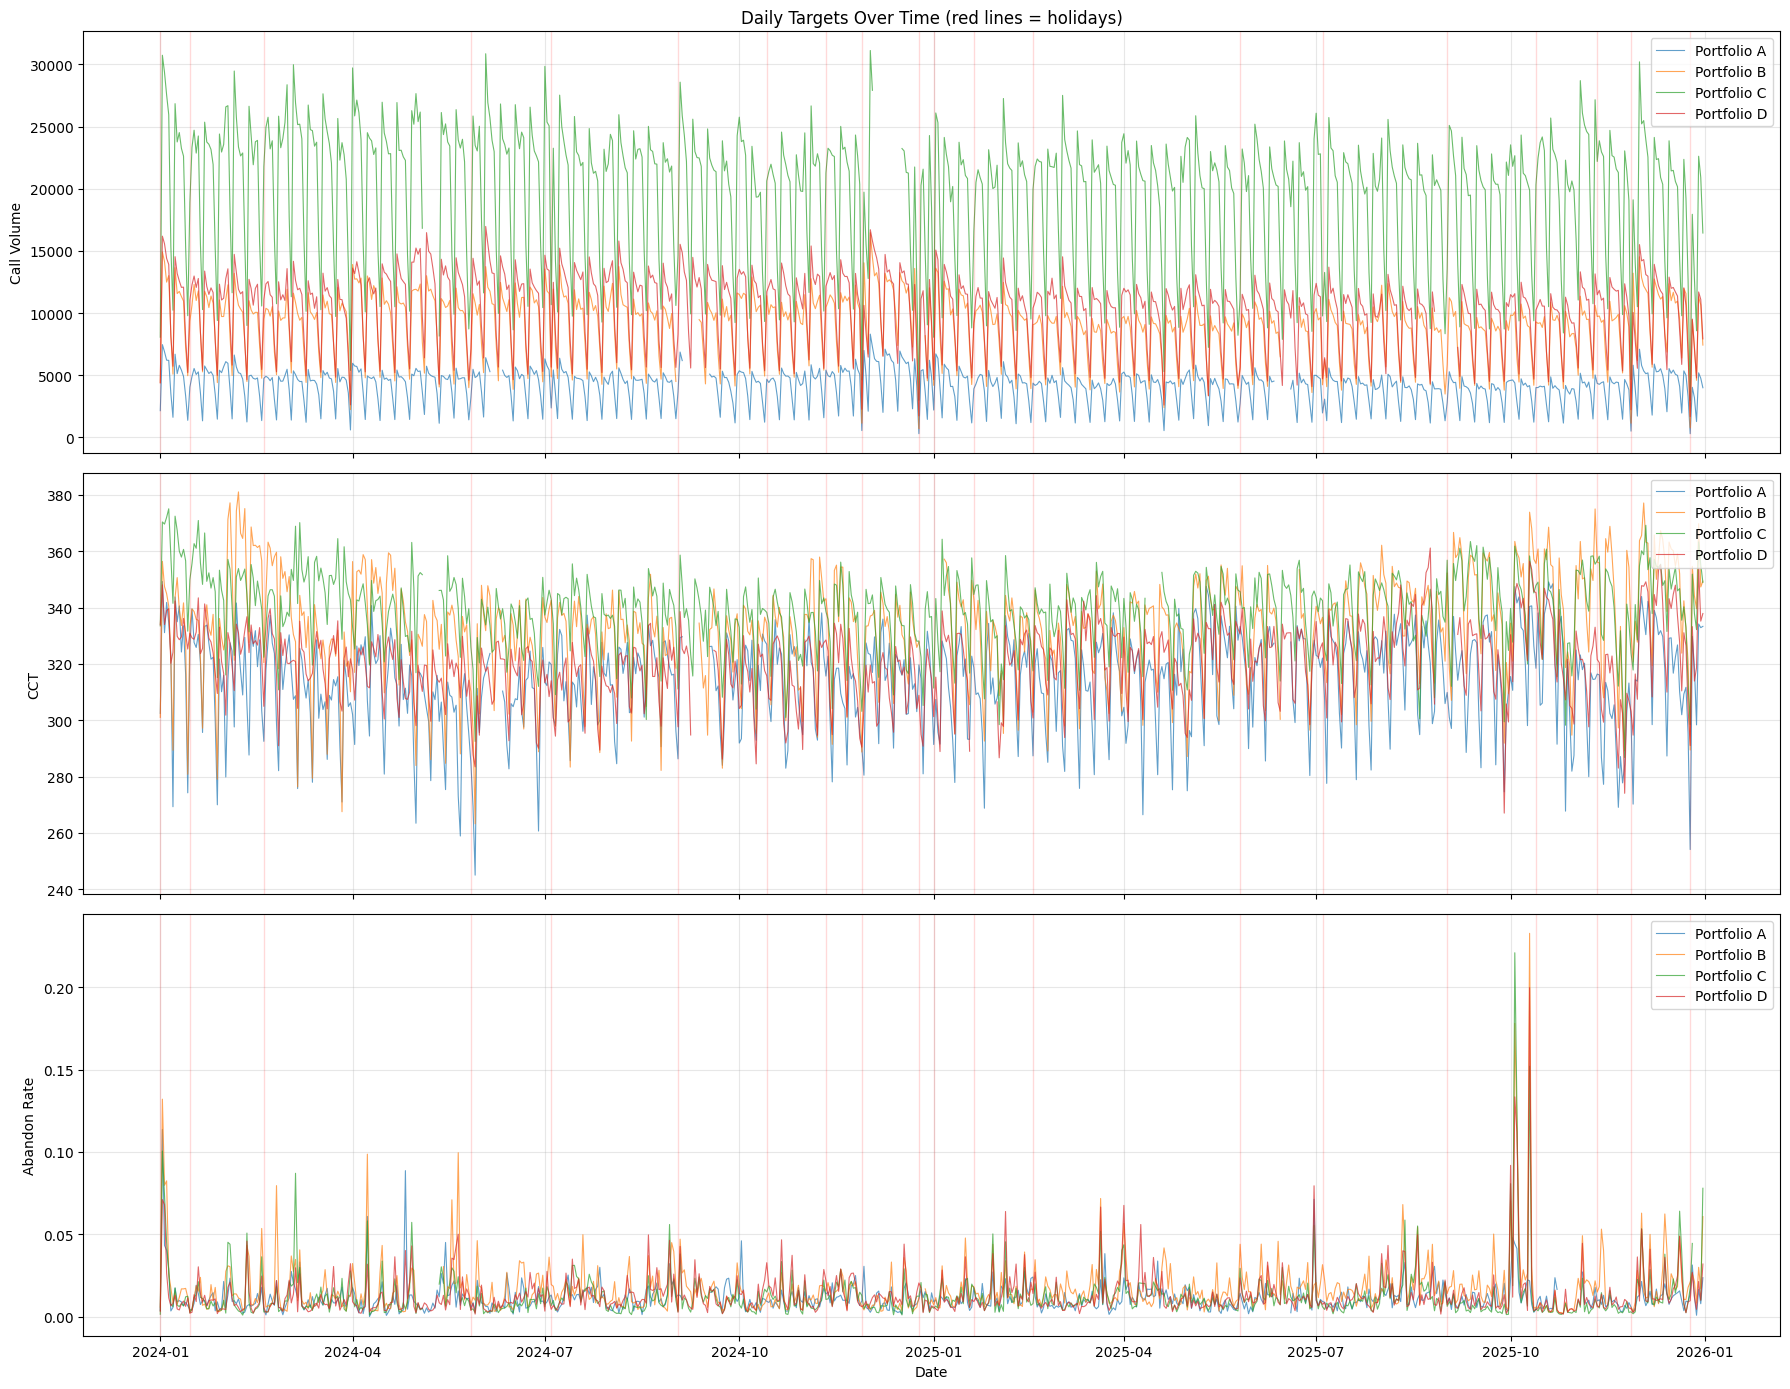

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
for i, metric in enumerate(metrics):
    ax = axes[i]
    for p in PORTFOLIOS:
        df = daily_data[p]
        ax.plot(df['Date'], df[metric], label=f'Portfolio {p}', alpha=0.7, linewidth=0.8)
    ax.set_ylabel(metric)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    for h in US_HOLIDAYS:
        if df['Date'].min() <= h <= df['Date'].max():
            ax.axvline(h, color='red', alpha=0.15, linewidth=1)
axes[0].set_title('Daily Targets Over Time (red lines = holidays)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 5. Weekday x Hour Heatmaps (Interval Data)

Core view — shows the intraday profile varies by day of week.

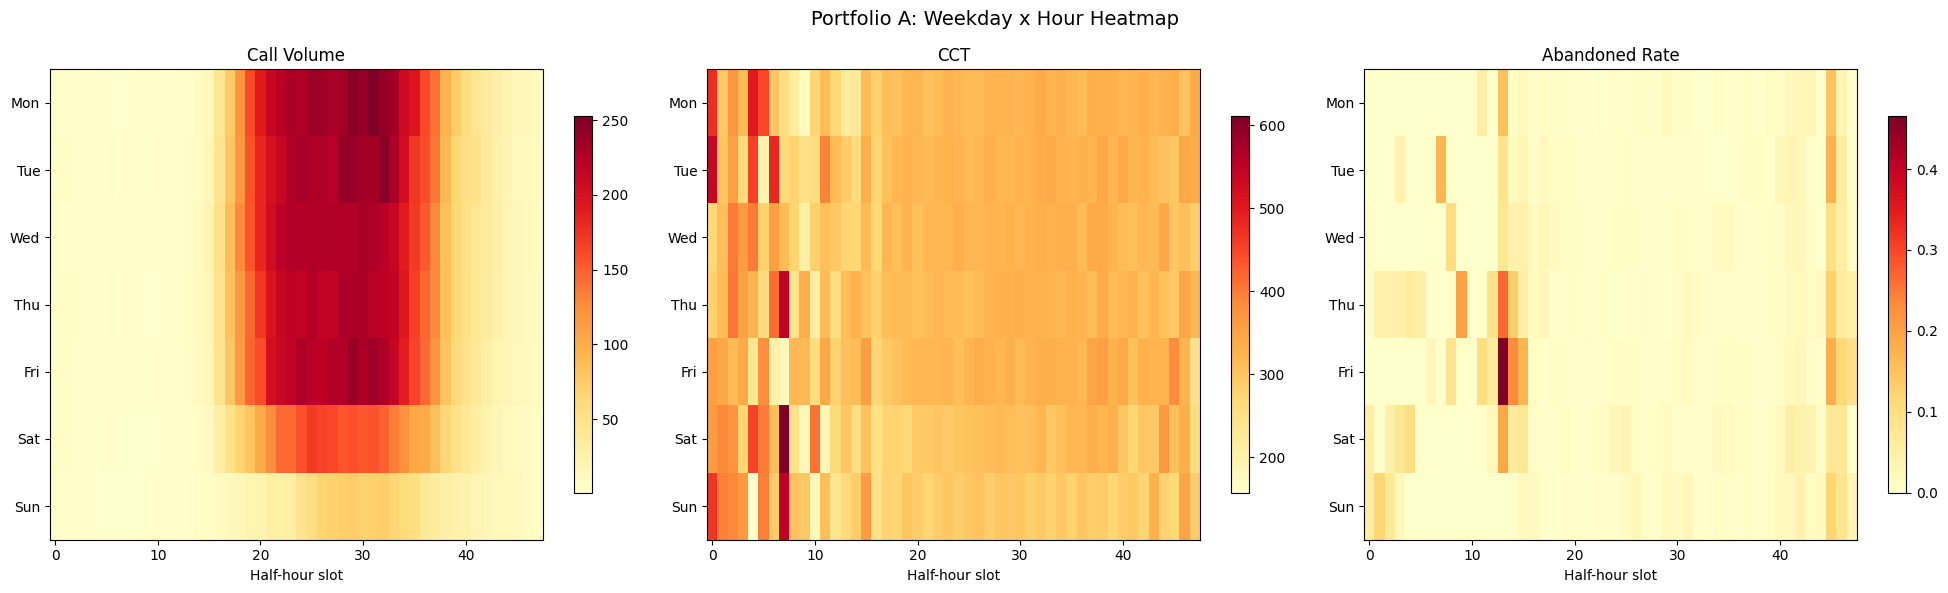

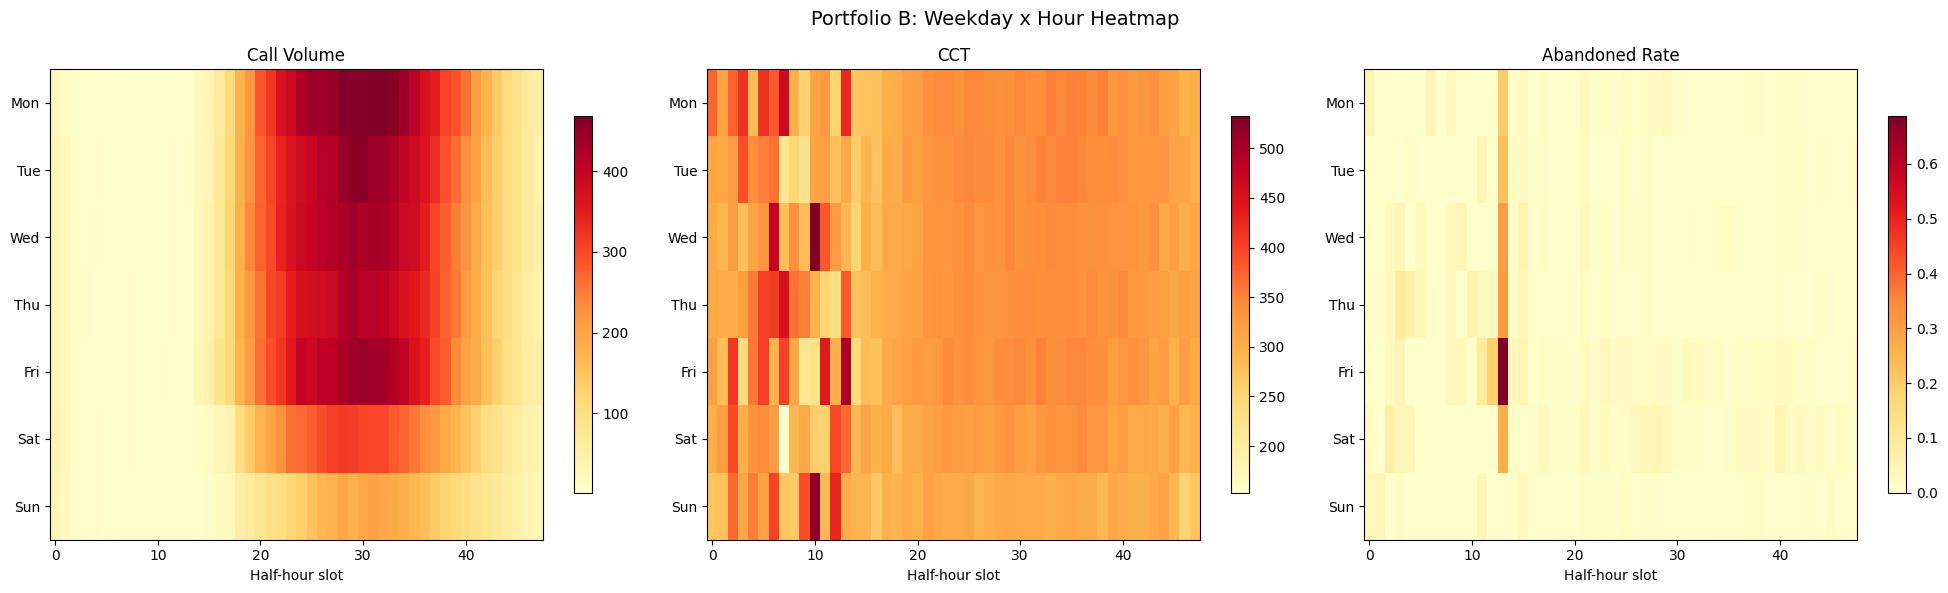

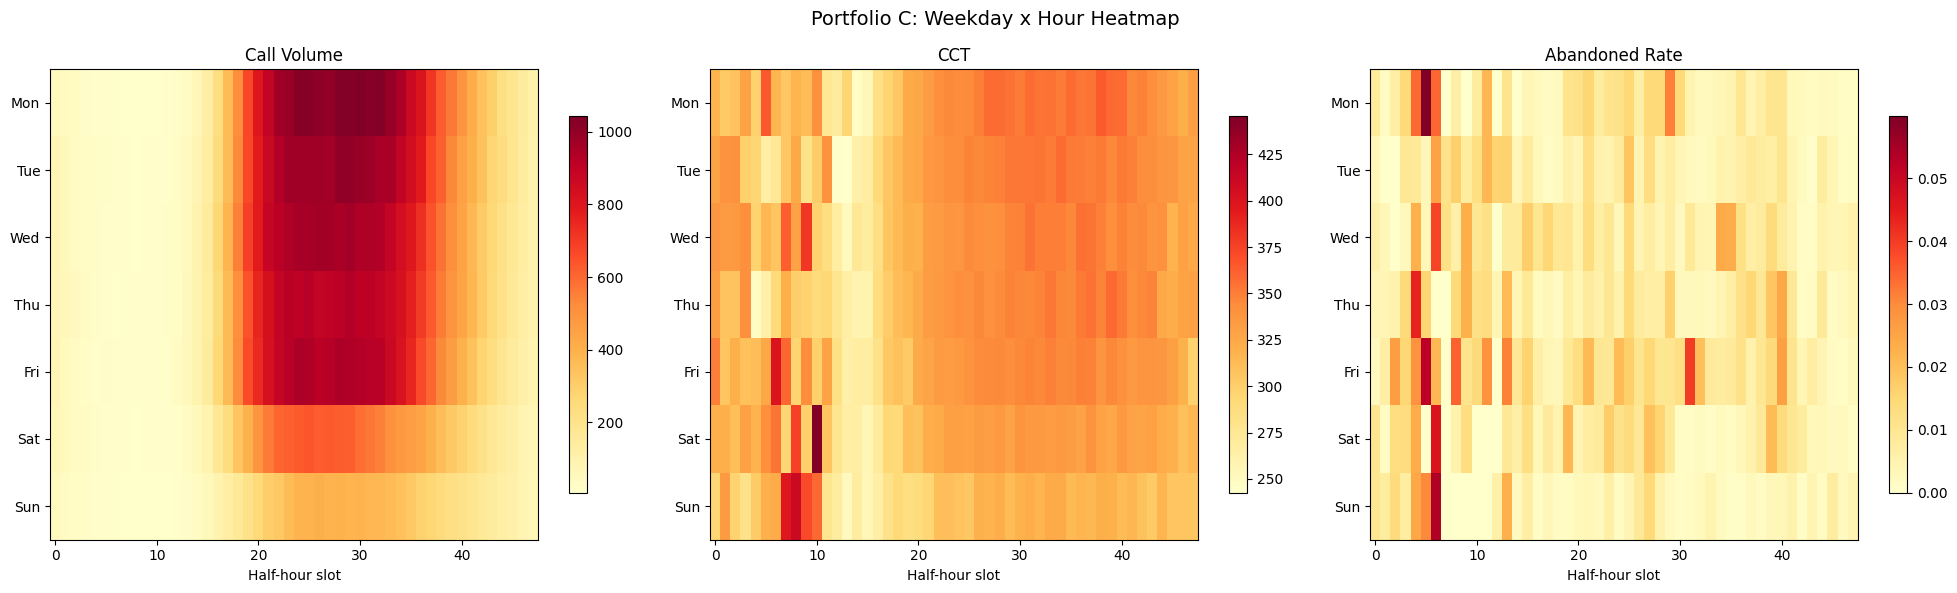

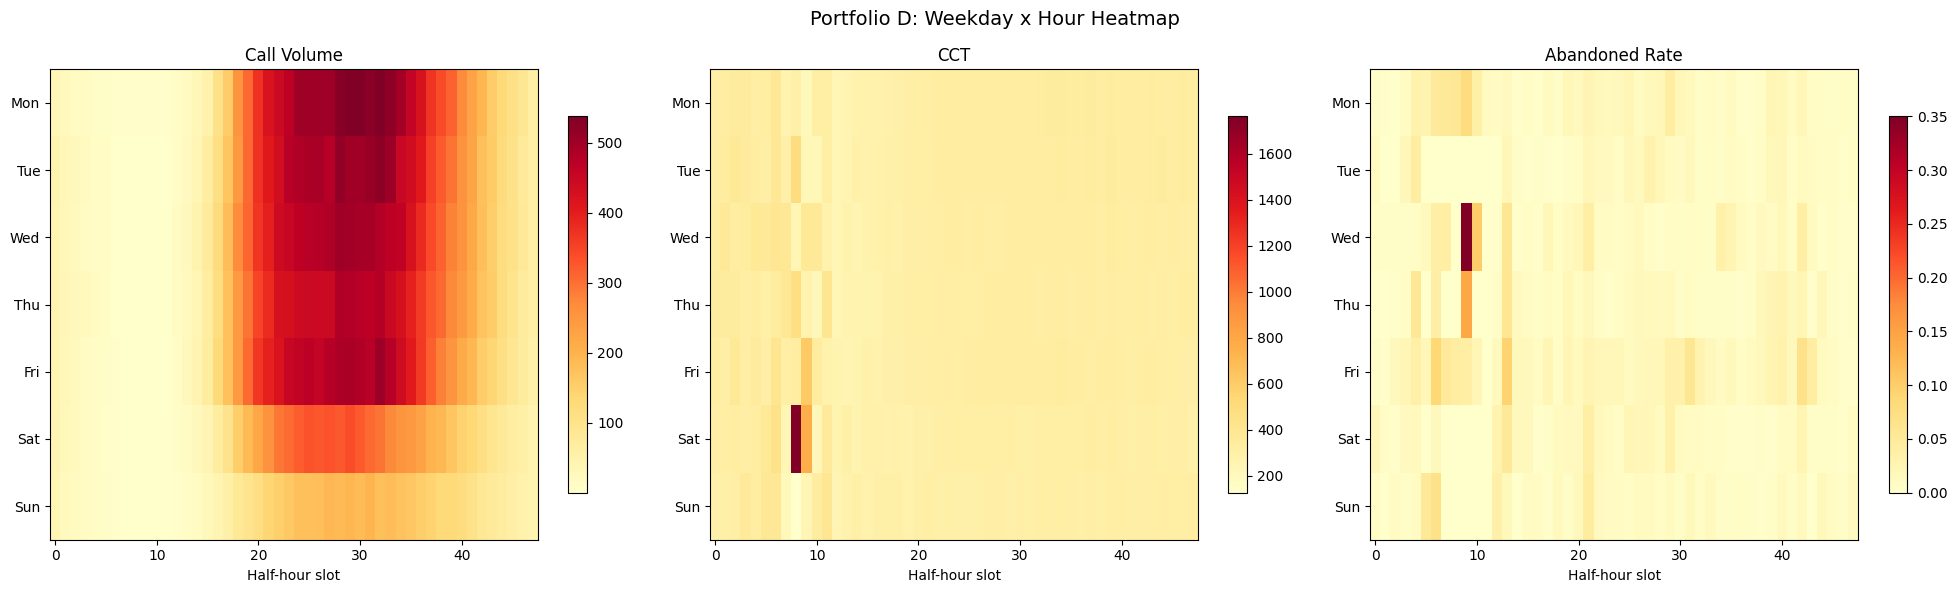

In [7]:
for p in PORTFOLIOS:
    df = interval_data[p]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for i, metric in enumerate(interval_metrics):
        ax = axes[i]
        pivot = df.pivot_table(values=metric, index='dow', columns='half_hour', aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
        ax.set_yticks(range(7))
        ax.set_yticklabels(dow_names)
        ax.set_xlabel('Half-hour slot')
        ax.set_title(metric)
        plt.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle(f'Portfolio {p}: Weekday x Hour Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Holiday Effects

HOLIDAY EFFECTS (daily Call Volume):
Portfolio A: Holiday avg=2907, Weekday avg=4873, Weekend avg=2353
  Holiday/Weekday ratio: 0.60, Weekend/Weekday ratio: 0.48
Portfolio B: Holiday avg=6173, Weekday avg=10446, Weekend avg=5925
  Holiday/Weekday ratio: 0.59, Weekend/Weekday ratio: 0.57
Portfolio C: Holiday avg=13257, Weekday avg=22831, Weekend avg=12105
  Holiday/Weekday ratio: 0.58, Weekend/Weekday ratio: 0.53
Portfolio D: Holiday avg=7144, Weekday avg=12063, Weekend avg=6435
  Holiday/Weekday ratio: 0.59, Weekend/Weekday ratio: 0.53


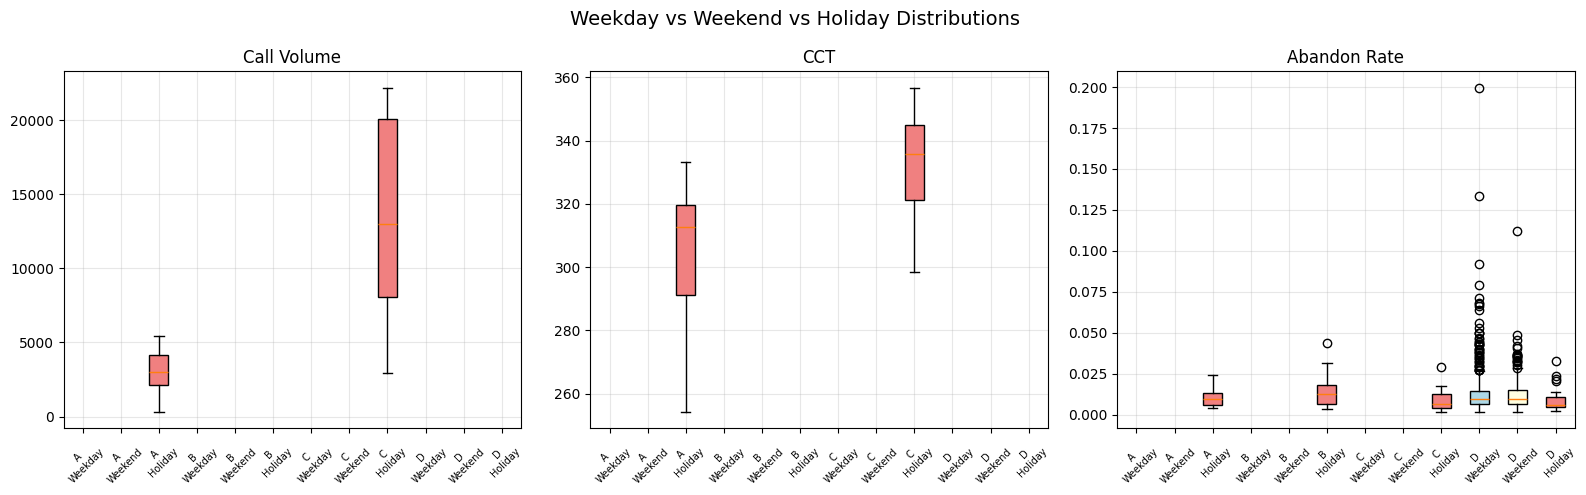

In [8]:
print("HOLIDAY EFFECTS (daily Call Volume):")
for p in PORTFOLIOS:
    df = daily_data[p]
    hol = df[df['is_holiday'] == 1]['Call Volume'].mean()
    non_hol_wd = df[(df['is_holiday'] == 0) & (df['is_weekend'] == 0)]['Call Volume'].mean()
    wkend = df[df['is_weekend'] == 1]['Call Volume'].mean()
    print(f"Portfolio {p}: Holiday avg={hol:.0f}, Weekday avg={non_hol_wd:.0f}, Weekend avg={wkend:.0f}")
    print(f"  Holiday/Weekday ratio: {hol/non_hol_wd:.2f}, Weekend/Weekday ratio: {wkend/non_hol_wd:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(metrics):
    ax = axes[i]
    data_to_plot = []
    labels = []
    for p in PORTFOLIOS:
        df = daily_data[p]
        non_hol = df[(df['is_holiday'] == 0) & (df['is_weekend'] == 0)][metric]
        wkend = df[df['is_weekend'] == 1][metric]
        hol = df[df['is_holiday'] == 1][metric]
        data_to_plot.extend([non_hol, wkend, hol])
        labels.extend([f'{p}\nWeekday', f'{p}\nWeekend', f'{p}\nHoliday'])
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    colors = ['lightblue', 'lightyellow', 'lightcoral'] * 4
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle('Weekday vs Weekend vs Holiday Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Autocorrelation (Daily + Interval)

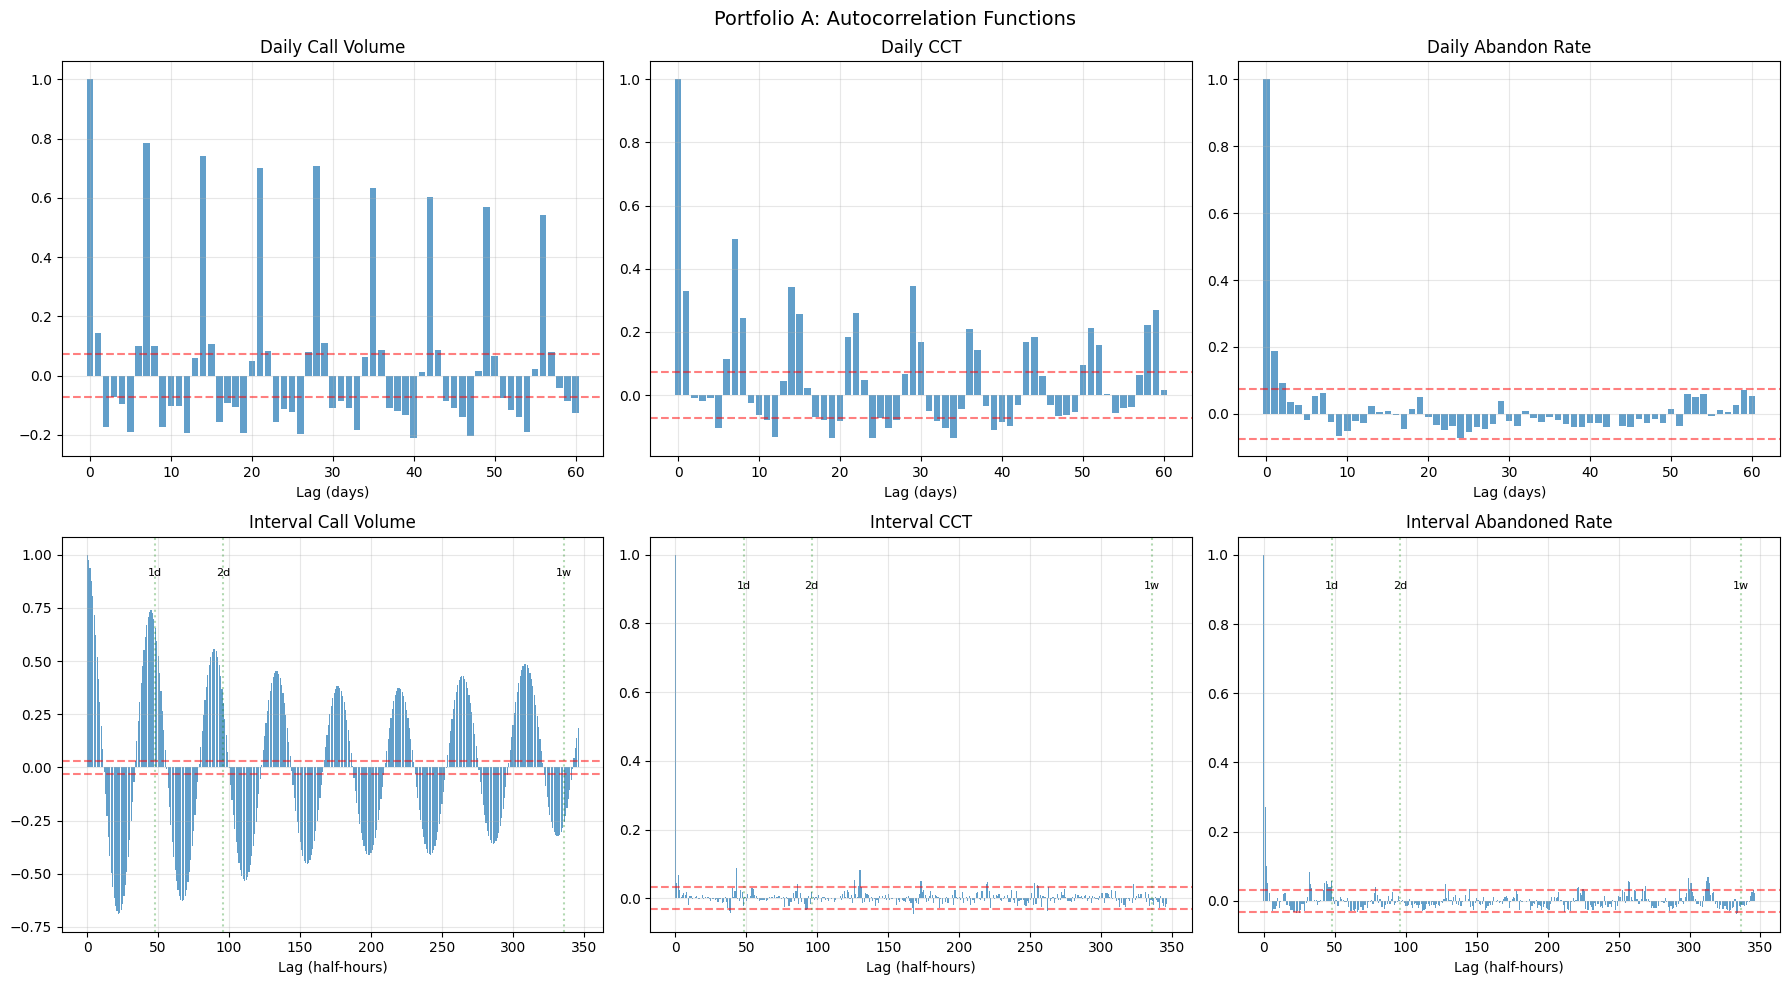

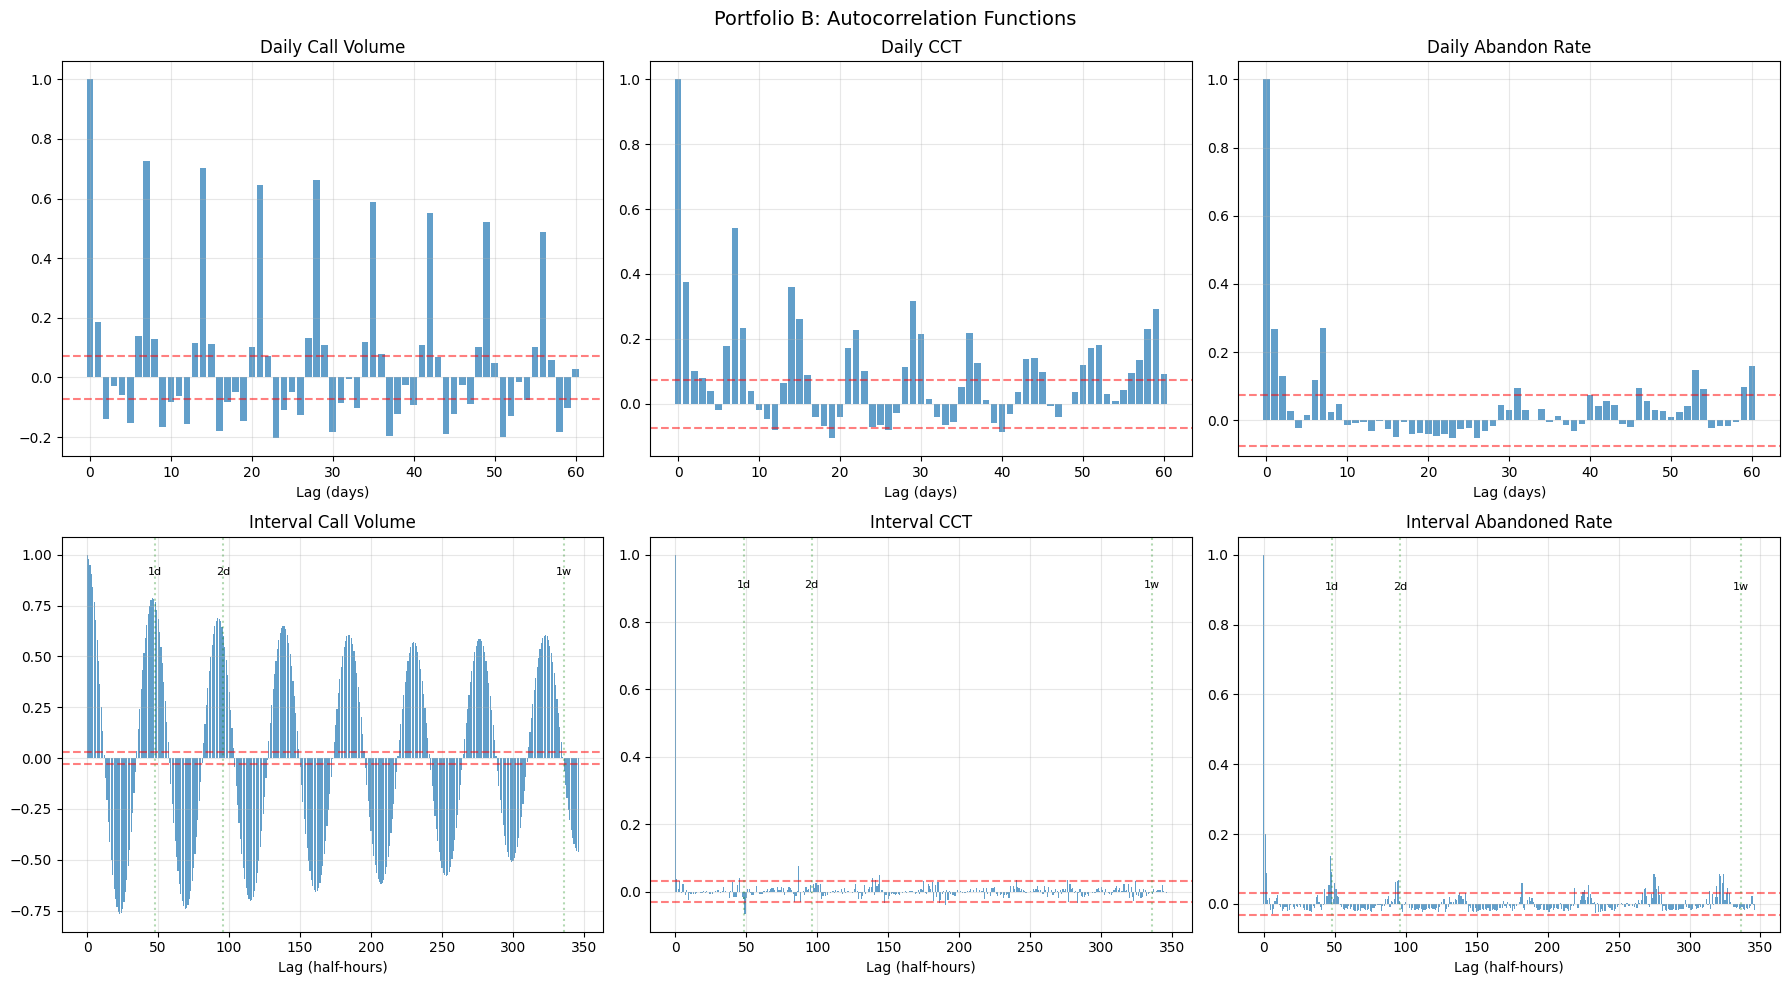

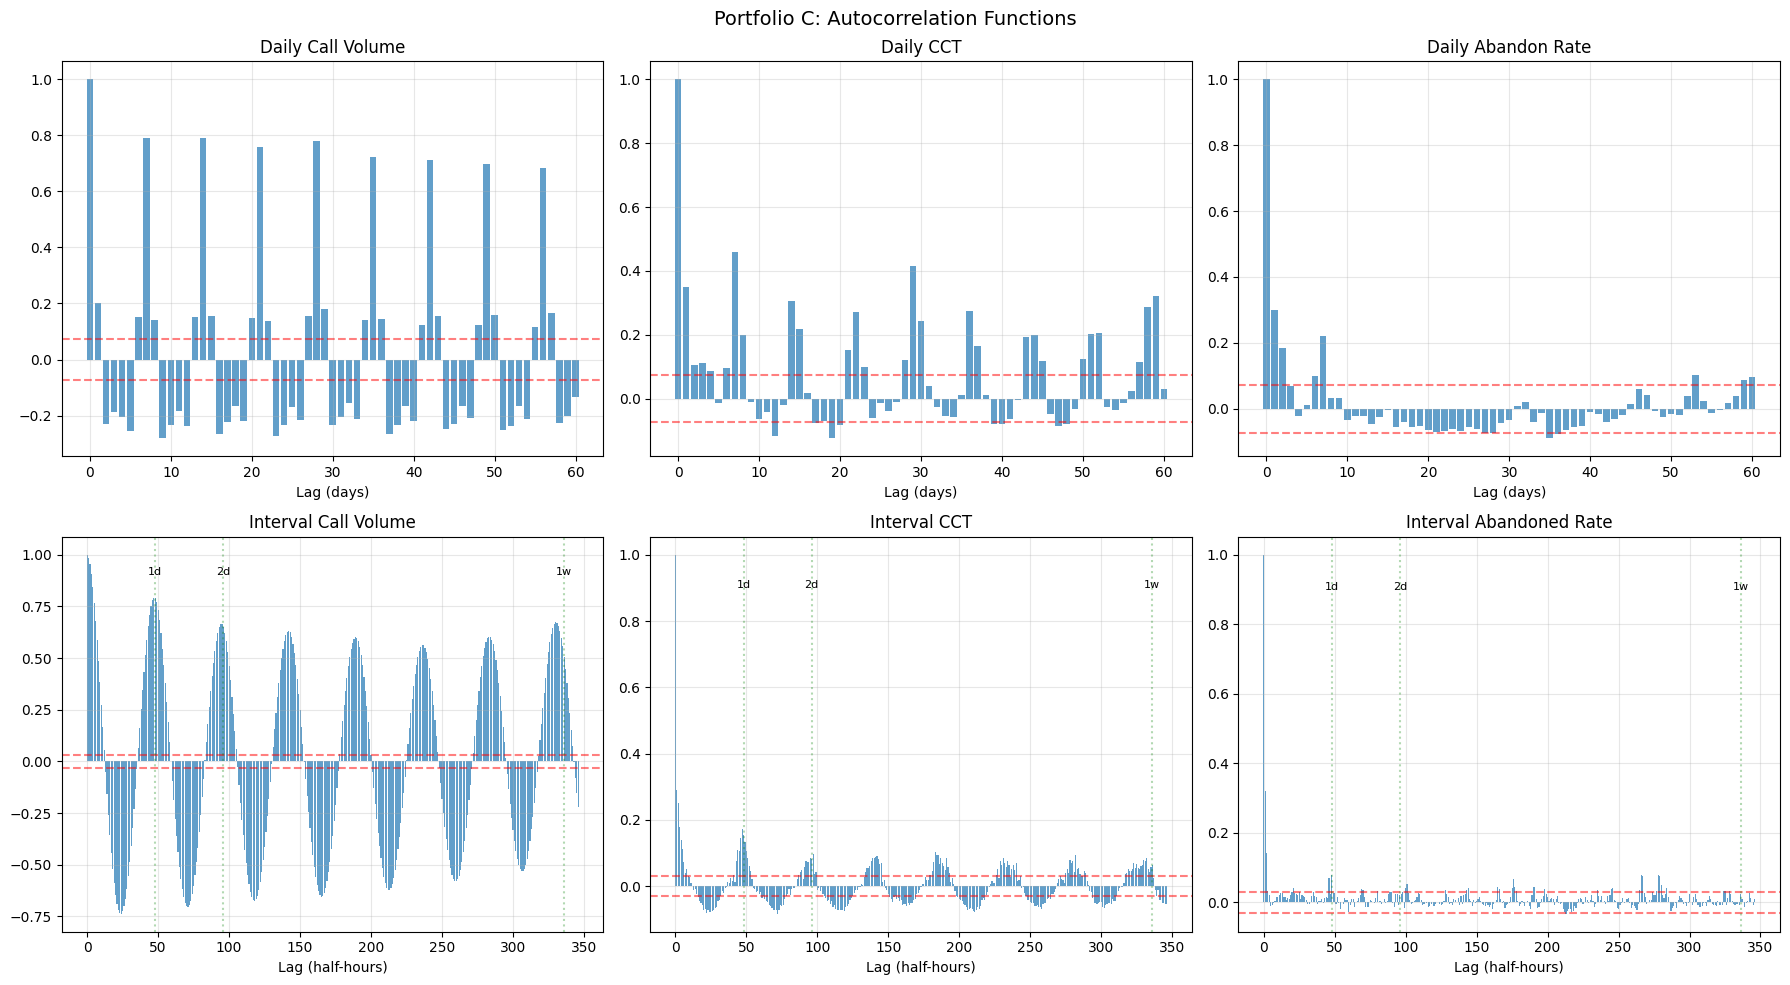

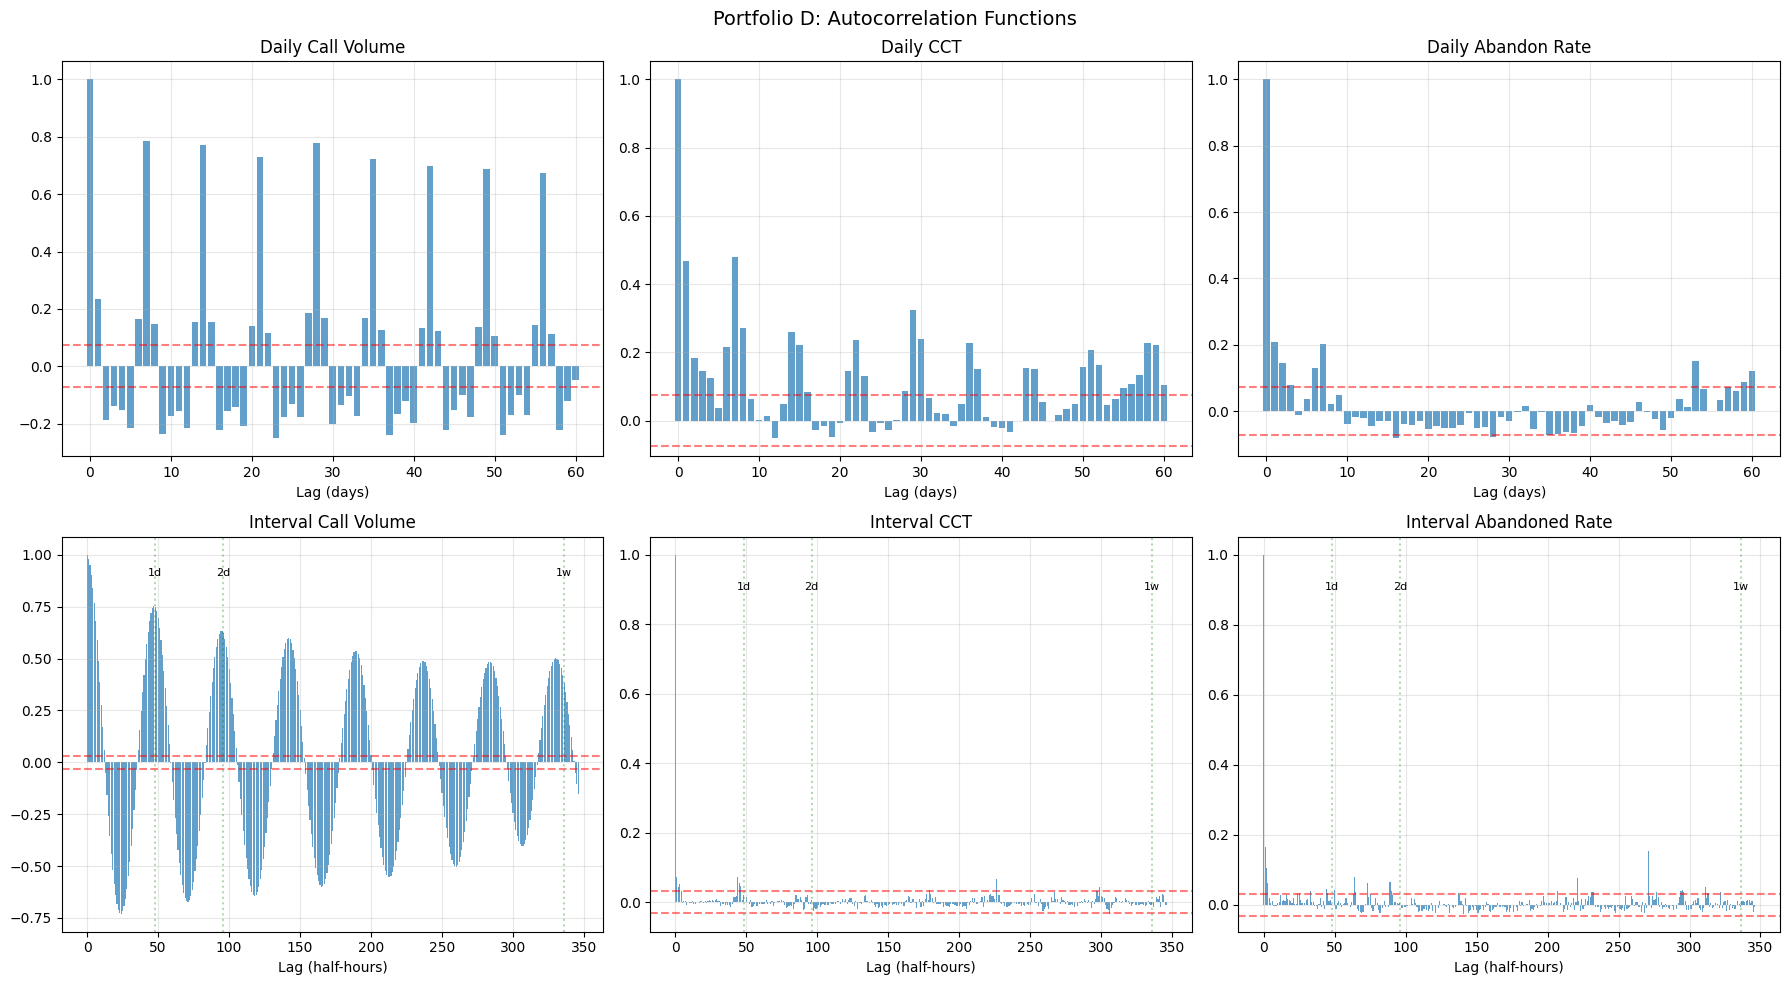

In [9]:
for p in PORTFOLIOS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, metric in enumerate(metrics):
        ax = axes[0, i]
        vals = daily_data[p][metric].dropna().values
        nlags = min(60, len(vals) - 1)
        acf_vals = compute_acf(vals, nlags=nlags, fft=True)
        ax.bar(range(len(acf_vals)), acf_vals, width=0.8, alpha=0.7)
        ax.axhline(1.96/np.sqrt(len(vals)), color='red', linestyle='--', alpha=0.5)
        ax.axhline(-1.96/np.sqrt(len(vals)), color='red', linestyle='--', alpha=0.5)
        ax.set_title(f'Daily {metric}')
        ax.set_xlabel('Lag (days)')
        ax.grid(True, alpha=0.3)

    idf = interval_data[p].sort_values(['Date', 'half_hour'])
    for i, metric in enumerate(interval_metrics):
        ax = axes[1, i]
        vals = idf[metric].dropna().values
        nlags = min(48 * 7 + 10, len(vals) - 1)
        acf_vals = compute_acf(vals, nlags=nlags, fft=True)
        ax.bar(range(len(acf_vals)), acf_vals, width=0.8, alpha=0.7)
        ax.axhline(1.96/np.sqrt(len(vals)), color='red', linestyle='--', alpha=0.5)
        ax.axhline(-1.96/np.sqrt(len(vals)), color='red', linestyle='--', alpha=0.5)
        for lag, label in [(48, '1d'), (96, '2d'), (336, '1w')]:
            if lag < len(acf_vals):
                ax.axvline(lag, color='green', alpha=0.3, linestyle=':')
                ax.text(lag, max(acf_vals) * 0.9, label, fontsize=8, ha='center')
        ax.set_title(f'Interval {metric}')
        ax.set_xlabel('Lag (half-hours)')
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Portfolio {p}: Autocorrelation Functions', fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Stationarity Tests (ADF & KPSS)

Needed to justify model choice — whether differencing is required.

In [10]:
print(f"{'Portfolio':<10} {'Metric':<15} {'ADF stat':>10} {'ADF p':>8} {'ADF result':>14} {'KPSS stat':>10} {'KPSS p':>8} {'KPSS result':>14}")
print("-" * 95)

for p in PORTFOLIOS:
    df = daily_data[p]
    for metric in metrics:
        vals = df[metric].dropna().values

        adf_stat, adf_p, *_ = adfuller(vals, autolag='AIC')
        adf_result = 'Stationary' if adf_p < 0.05 else 'Non-stationary'

        kpss_stat, kpss_p, *_ = kpss(vals, regression='c', nlags='auto')
        kpss_result = 'Stationary' if kpss_p > 0.05 else 'Non-stationary'

        print(f"{p:<10} {metric:<15} {adf_stat:>10.3f} {adf_p:>8.4f} {adf_result:>14} {kpss_stat:>10.3f} {kpss_p:>8.4f} {kpss_result:>14}")
    print()


Portfolio  Metric            ADF stat    ADF p     ADF result  KPSS stat   KPSS p    KPSS result
-----------------------------------------------------------------------------------------------
A          Call Volume         -2.859   0.0503 Non-stationary      1.366   0.0100 Non-stationary
A          CCT                 -4.554   0.0002     Stationary      0.753   0.0100 Non-stationary
A          Abandon Rate       -21.829   0.0000     Stationary      0.059   0.1000     Stationary

B          Call Volume         -3.079   0.0281     Stationary      1.983   0.0100 Non-stationary
B          CCT                 -4.266   0.0005     Stationary      1.210   0.0100 Non-stationary
B          Abandon Rate        -6.266   0.0000     Stationary      0.599   0.0227 Non-stationary

C          Call Volume         -2.304   0.1706 Non-stationary      0.832   0.0100 Non-stationary
C          CCT                 -5.704   0.0000     Stationary      0.583   0.0242 Non-stationary
C          Abandon Rate      

## 9. STL Decomposition (Trend / Seasonal / Residual)

Decompose daily Call Volume to see what's left after removing trend and weekly seasonality.

Portfolio A residual: mean=-8.5, std=634.4, % of original std=44.7%
Portfolio B residual: mean=-159.5, std=1331.1, % of original std=50.3%
Portfolio C residual: mean=-172.5, std=2505.2, % of original std=44.4%
Portfolio D residual: mean=-106.7, std=1237.6, % of original std=41.3%


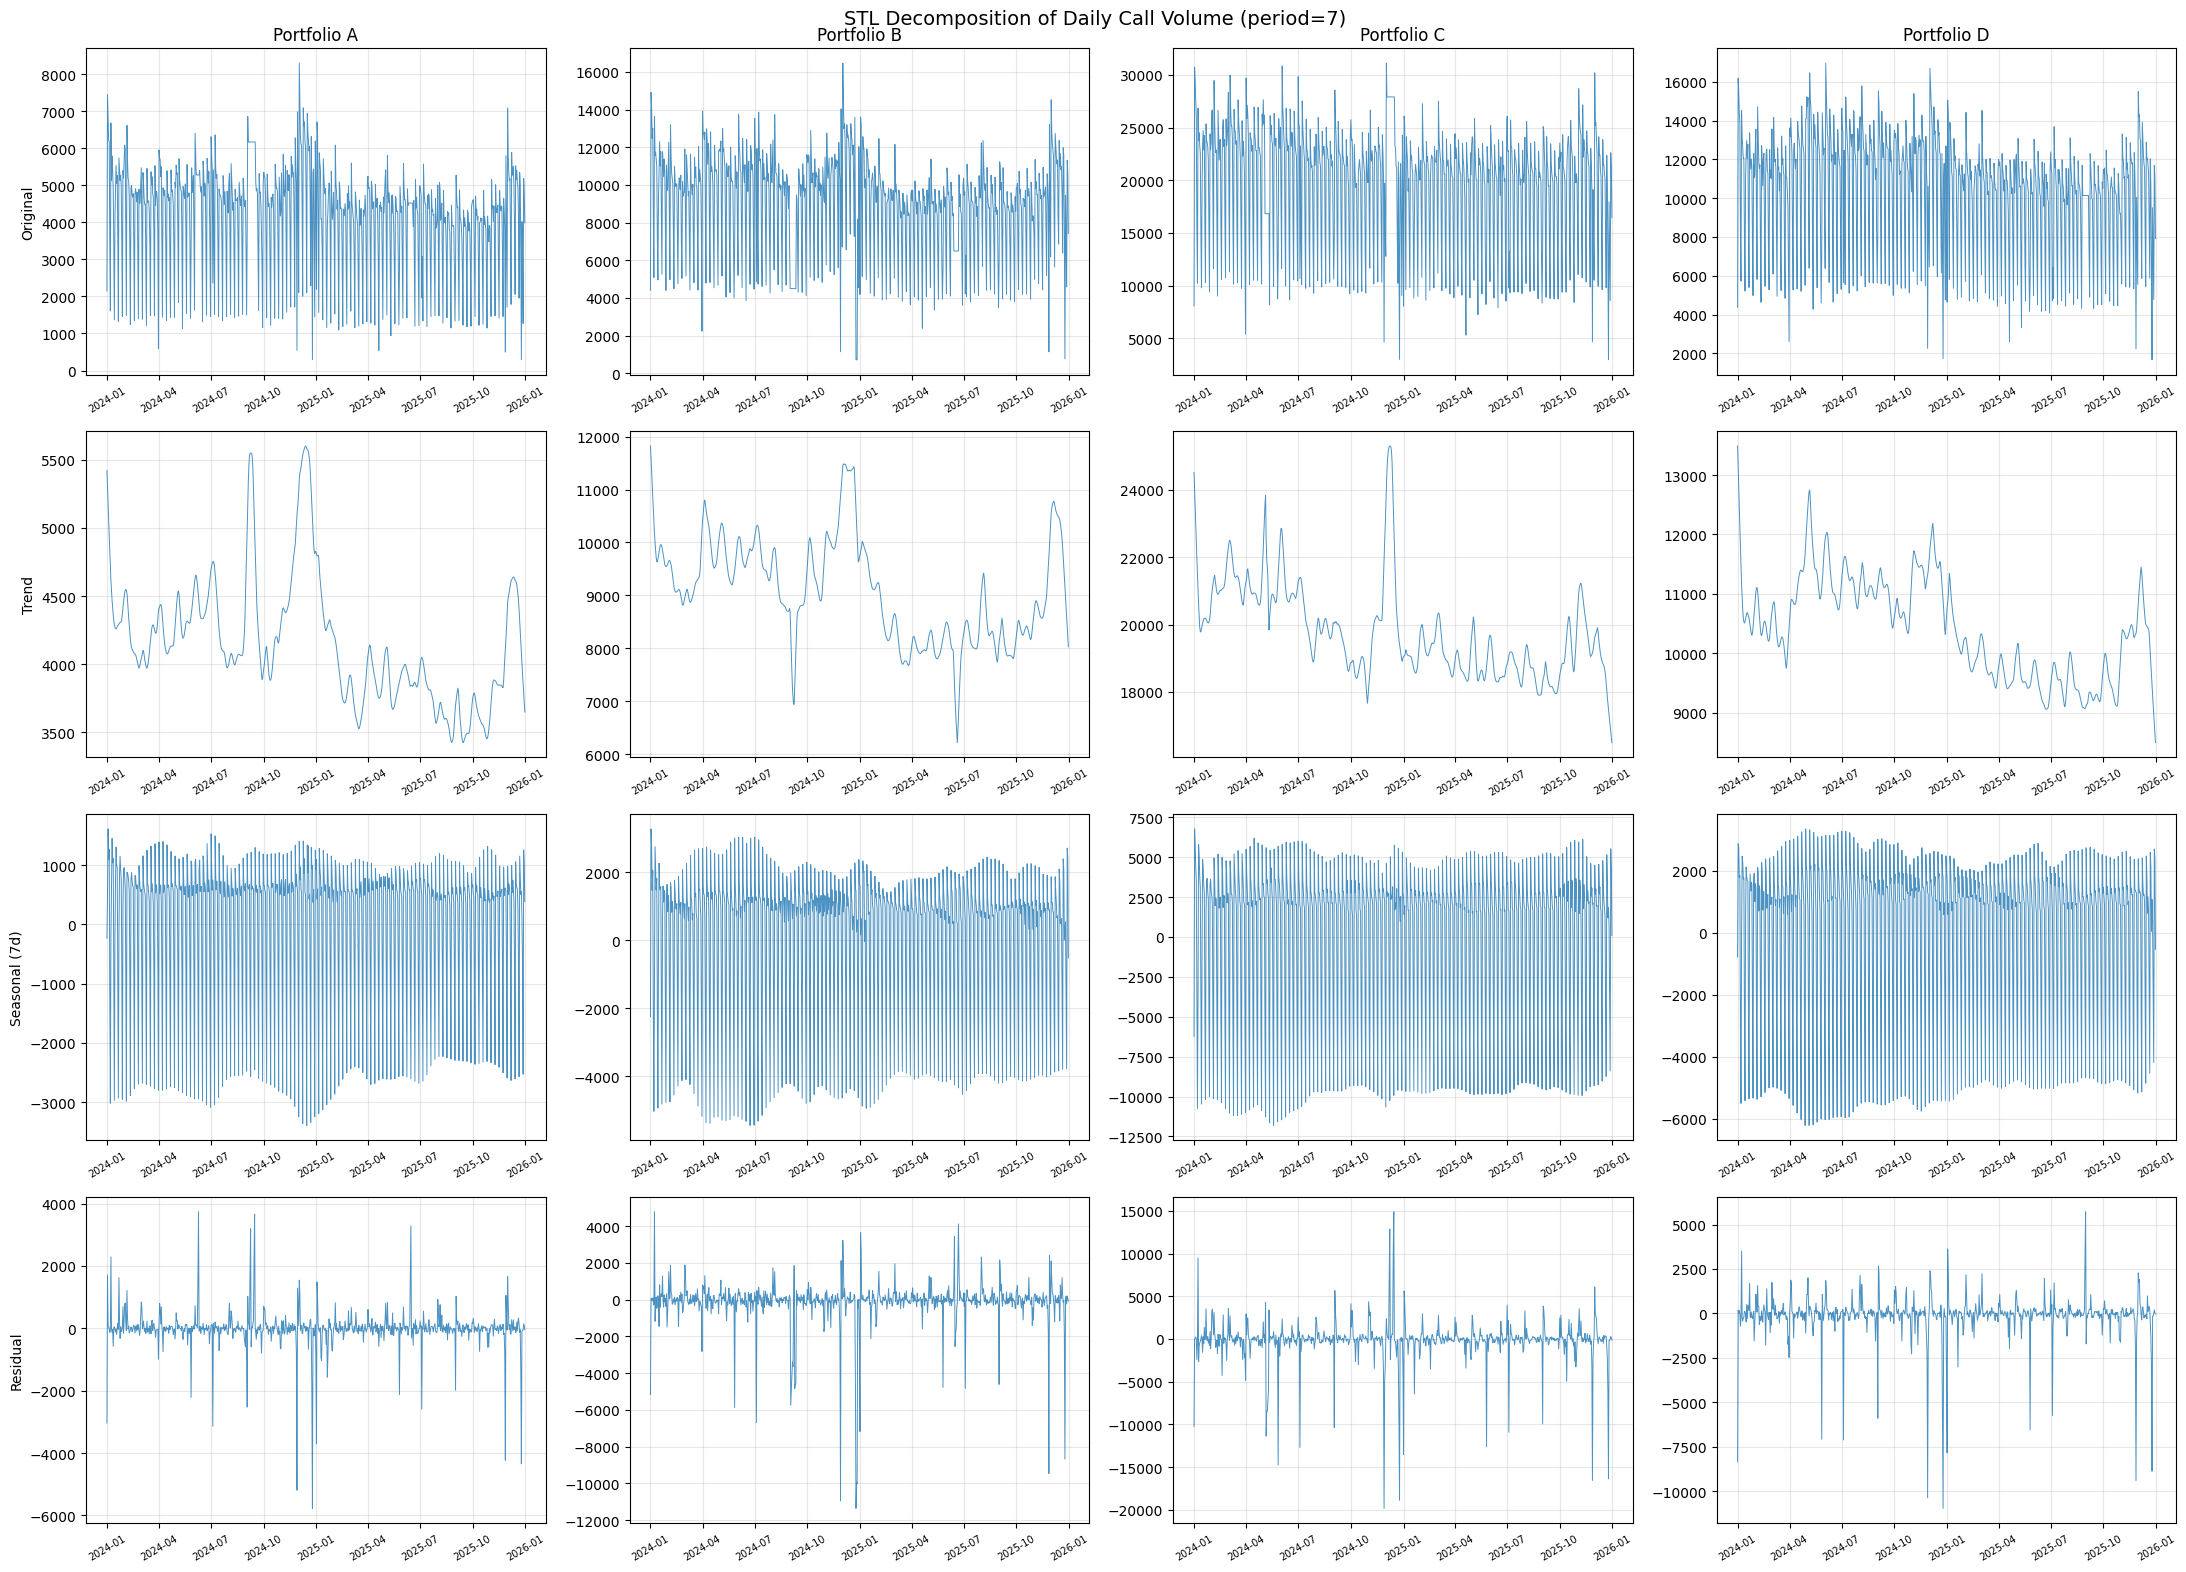

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(22, 16))
component_names = ['Original', 'Trend', 'Seasonal (7d)', 'Residual']

for j, p in enumerate(PORTFOLIOS):
    df = daily_data[p].set_index('Date')['Call Volume'].dropna()
    df = df.asfreq('D', method='ffill')

    stl = STL(df, period=7, robust=True)
    result = stl.fit()

    components = [df, result.trend, result.seasonal, result.resid]
    for i, (comp, name) in enumerate(zip(components, component_names)):
        ax = axes[i, j]
        ax.plot(comp.index, comp.values, linewidth=0.7, alpha=0.8)
        if i == 0:
            ax.set_title(f'Portfolio {p}', fontsize=12)
        if j == 0:
            ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

    resid = result.resid
    print(f"Portfolio {p} residual: mean={resid.mean():.1f}, std={resid.std():.1f}, "
          f"% of original std={resid.std()/df.std()*100:.1f}%")

fig.suptitle('STL Decomposition of Daily Call Volume (period=7)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Outlier Detection

Flag days where Call Volume deviates >3 sigma from a 7-day rolling mean. These could hurt training if not handled.

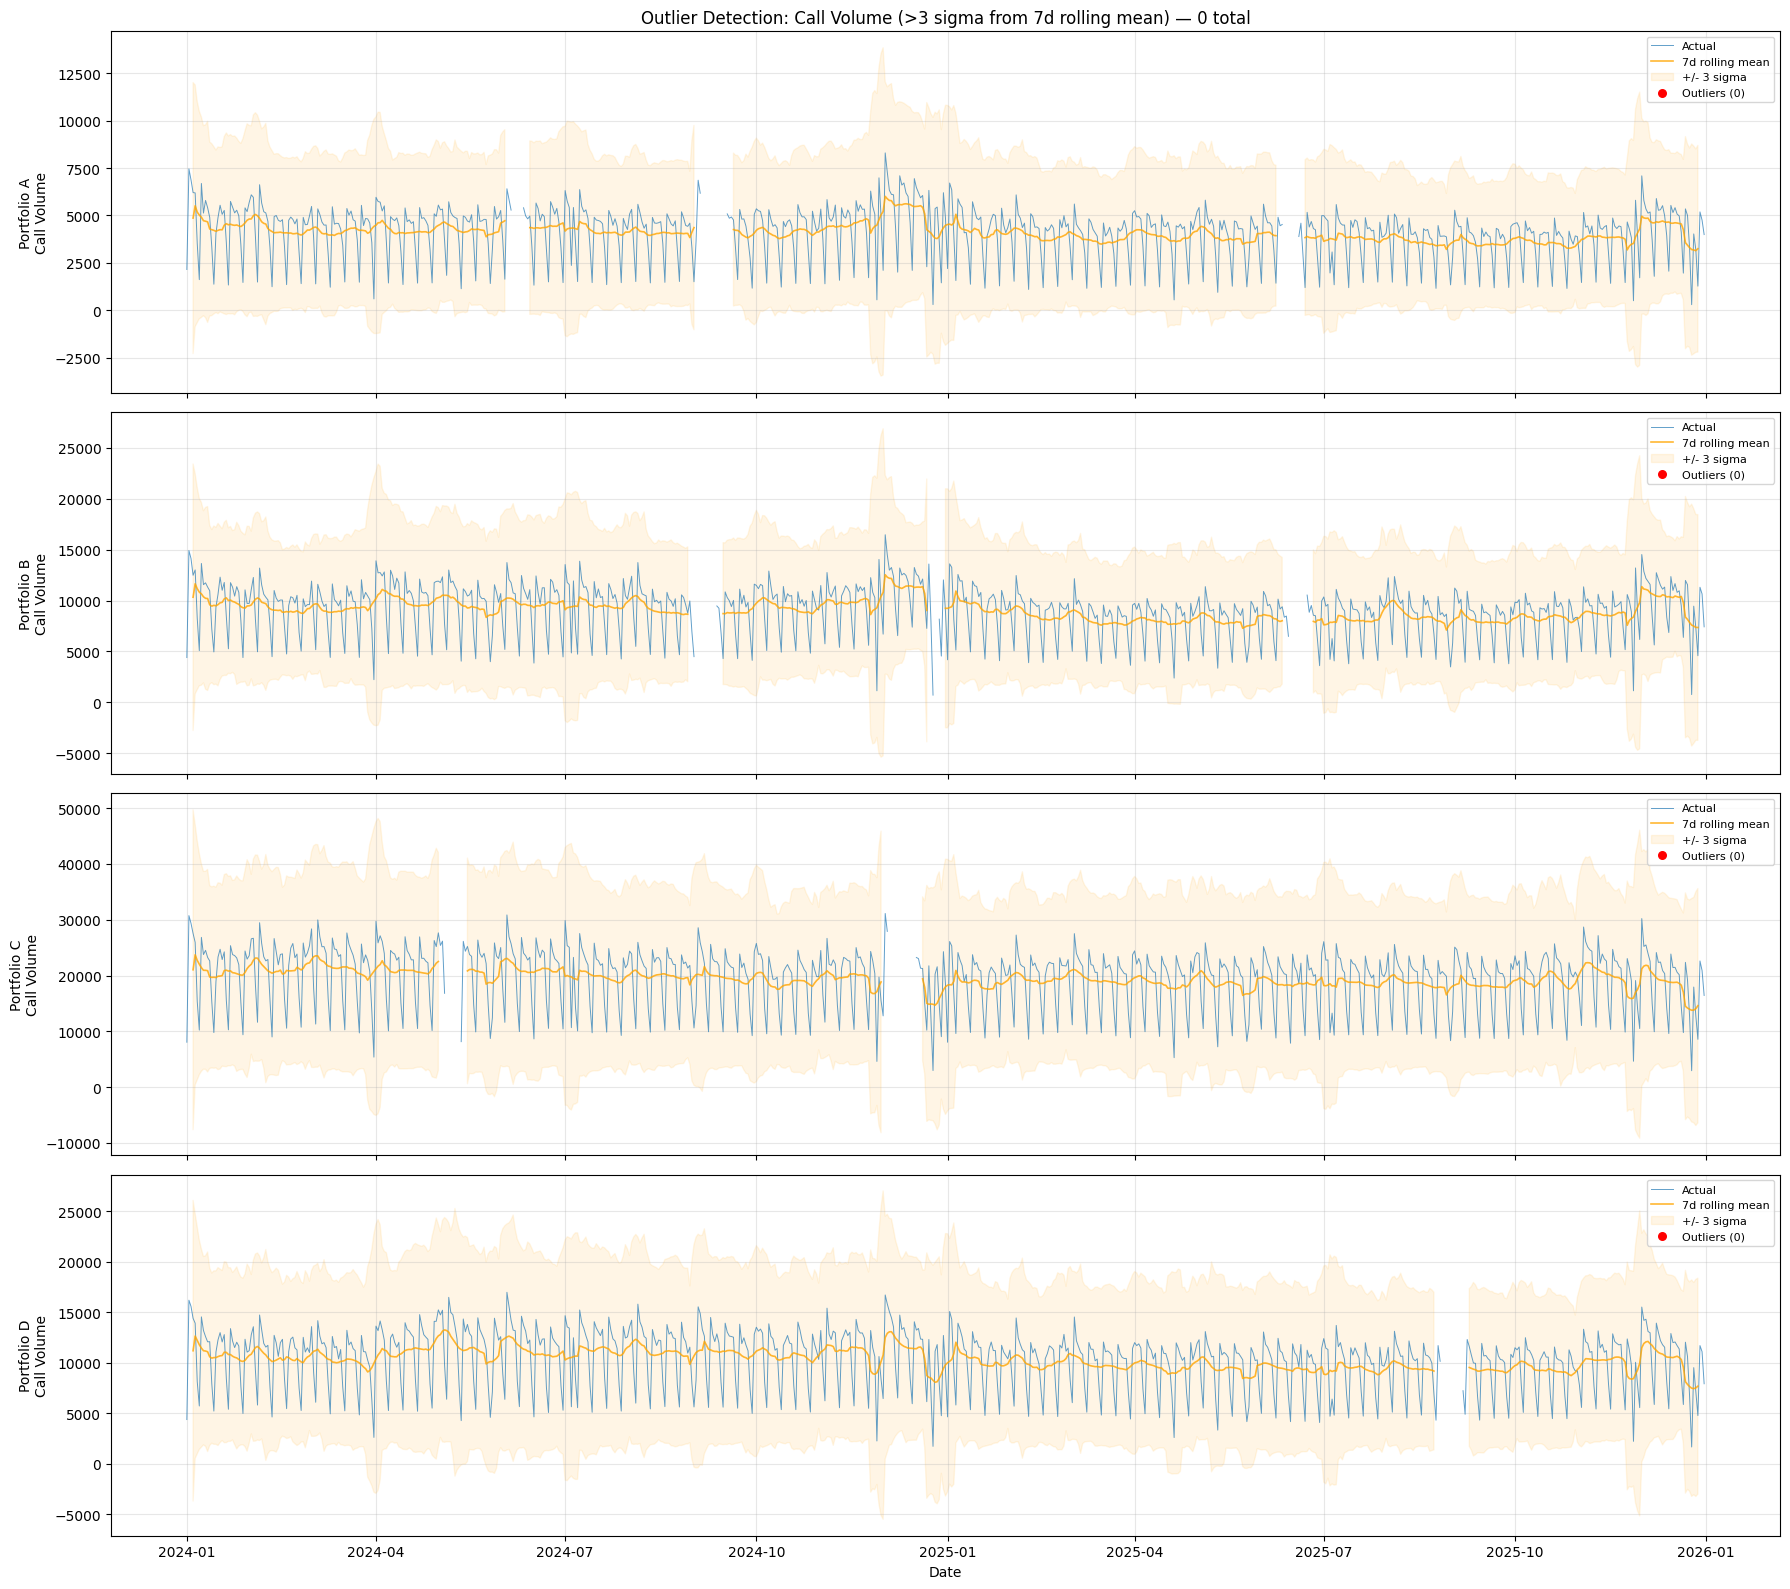

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)

total_outliers = 0
for j, p in enumerate(PORTFOLIOS):
    df = daily_data[p].copy()
    ax = axes[j]

    rolling_mean = df['Call Volume'].rolling(7, center=True).mean()
    rolling_std = df['Call Volume'].rolling(7, center=True).std()
    z_score = (df['Call Volume'] - rolling_mean) / rolling_std
    outlier_mask = (z_score.abs() > 3) & rolling_std.notna()

    ax.plot(df['Date'], df['Call Volume'], linewidth=0.7, alpha=0.7, label='Actual')
    ax.plot(df['Date'], rolling_mean, linewidth=1.2, alpha=0.8, color='orange', label='7d rolling mean')
    ax.fill_between(df['Date'],
                    rolling_mean - 3 * rolling_std,
                    rolling_mean + 3 * rolling_std,
                    alpha=0.1, color='orange', label='+/- 3 sigma')

    outliers = df[outlier_mask]
    ax.scatter(outliers['Date'], outliers['Call Volume'], color='red', s=30, zorder=5, label=f'Outliers ({len(outliers)})')
    total_outliers += len(outliers)

    if len(outliers) > 0:
        print(f"Portfolio {p} outliers ({len(outliers)} days):")
        for _, row in outliers.iterrows():
            rm = rolling_mean[row.name]
            print(f"  {row['Date'].date()} ({row['dow_name'][:3]}): "
                  f"{row['Call Volume']:.0f} vs rolling mean {rm:.0f} "
                  f"(z={z_score[row.name]:.1f})")

    ax.set_ylabel(f'Portfolio {p}\nCall Volume')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Outlier Detection: Call Volume (>3 sigma from 7d rolling mean) — {total_outliers} total')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 11. Findings Summary

731 days per portfolio, Jan 2024 through Dec 2025, no missing dates and no duplicates. Every metric has some NaN values scattered through the year (10-32 per portfolio) but nothing systematic. Abandon Rate is mostly zeros — 68.8% exact zero days on A, down to 48.2% on D. When it's non-zero, the values are tiny (mean 0.01-0.02), which is going to make it a hard target.

Interval data only covers April through June 2025 and Portfolio A has 87 days with fewer than 48 intervals. I'll need to filter to complete days when learning the intra-day profile, or the missing slots will skew the shape.

CCT has extreme tails on three portfolios. Kurtosis is 89.5 on A, 148.4 on B, and 858 on D. D is driven by one single day with a 4786-second CCT. Call Volume is actually well-behaved (kurtosis around -1.1), so heavy tails are a CCT/ABD problem, not a CV problem.

Day of week dominates the seasonal signal. Weekend volume is 48-57% of weekday. Holidays are a milder dip at 58-60% of weekday — so holidays and weekends are different magnitudes, not the same thing. I should encode them as separate features.

ADF and KPSS agree that CV is mostly non-stationary (A, C, D), CCT is trend-stationary on all four, and Abandon Rate is close to stationary on A, C, D. Lag features and rolling means should handle this without explicit differencing.

Daily ACF is dominated by lag-7 (same weekday). Interval ACF has clear lag-48 (same slot yesterday) and lag-336 (same slot last week) peaks. These map directly to the features I'll build.

STL residuals are 40-50% of the original std, which means trend + weekly seasonality only explain half the variance. The rest has to come from lags, staffing, and whatever else.

### Implications for the baseline

1. DOW has to be a feature
2. Holiday gets its own flag, separate from weekend
3. Stage 2 should use a DOW × half-hour disaggregation profile
4. CCT heavy tails might hurt squared-loss models — keep an eye on it
5. Abandon Rate is going to be hard. It's tiny, bounded, and half the days are zero. Regression on the raw rate probably won't work, but I'll see what Ridge does in NB2 first.

One thing I haven't tested here: whether staffing actually interacts non-linearly with any target. The heatmaps hint at it but nothing here is an actual statistical test. NB3 will look at Ridge residuals vs staffing and settle it.
